# Lab 5. Feature Engineering

Dataset: `Creditcard_Customer_Chun.csv`

This lab covers:
- Creating new features
- Encoding categorical features (One-Hot, Label Encoding, MultiLabelBinarizer)
- Feature scaling (Min–Max)

## Step1: Data checking

In [26]:
#Load package

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset: Creditcard_Customer_Chun.csv

In [ ]:
df = pd.read_csv(r"C:\Users\AYE MIN AUNG\Downloads\Creditcard_Customer_Chun.csv")
df.head()

,RowId,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited
0,1,15634602.0,Laura Gomez,619,France,$60K - $80K,Female,1/1/1957,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES
1,2,15647311.0,Park Min Woo,608,Spain,Less than $40K,M,1/1/1954,Single,83807.86,Blue,112542.58,TravelBenefits,NO
2,3,15619304.0,Michael Chen,502,France,$80K - $120K,Male,1/1/1965,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES
3,4,15701354.0,Sofia Rossi,699,France,Less than $40K,F,1/1/1984,Unknown,0.00,Blue,93826.63,OnlineBanking,NO
4,5,15737888.0,Rachel Sanders,850,Spain,$60K - $80K,Male,1/1/1981,Married,125510.82,Blue,79084.10,Rewards,NO


### Check basic overview shape and info

In [28]:
# Basic overview
print(df.shape)
df.info()

(200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowId            200 non-null    int64  
 1   CustomerId       199 non-null    float64
 2   CustomerName     198 non-null    str    
 3   CreditScore      200 non-null    int64  
 4   Geography        199 non-null    str    
 5   Income_Category  200 non-null    str    
 6   Gender           195 non-null    str    
 7   DateOfBirth      200 non-null    str    
 8   Marital_Status   200 non-null    str    
 9   Balance          200 non-null    float64
 10  Card_Category    200 non-null    str    
 11  EstimatedSalary  200 non-null    float64
 12  ServicesUsed     200 non-null    str    
 13  Exited           200 non-null    str    
dtypes: float64(3), int64(2), str(9)
memory usage: 22.0 KB


### Check null value

In [29]:
# check null value
df.isnull().sum()

RowId              0
CustomerId         1
CustomerName       2
CreditScore        0
Geography          1
Income_Category    0
Gender             5
DateOfBirth        0
Marital_Status     0
Balance            0
Card_Category      0
EstimatedSalary    0
ServicesUsed       0
Exited             0
dtype: int64

## Step2: Data Cleaning
### Drop NaN value in very row of column of CustomerId, CustomerName and Gender
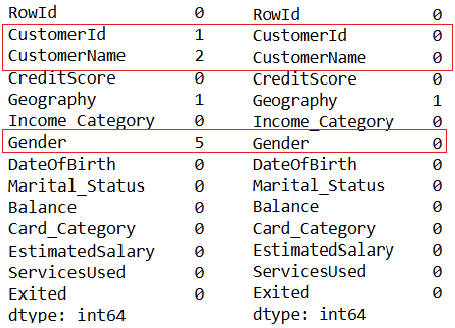

In [30]:
# Drop subset column of CustomerId, CustomerName and Gender is "Null"
df.dropna(subset=['CustomerId', 'CustomerName','Gender'], inplace =True)


In [31]:
#Check null value
df.isnull().sum()

RowId              0
CustomerId         0
CustomerName       0
CreditScore        0
Geography          1
Income_Category    0
Gender             0
DateOfBirth        0
Marital_Status     0
Balance            0
Card_Category      0
EstimatedSalary    0
ServicesUsed       0
Exited             0
dtype: int64

### Drop column "RowId ", axis=1,inplace=True
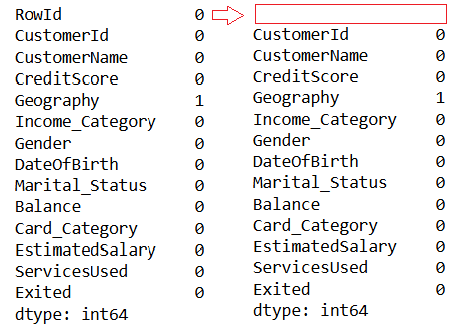

In [32]:
#drop row RowId
df.drop('RowId', axis=1, inplace=True)



In [33]:
#Check null value
df.isnull().sum()

CustomerId         0
CustomerName       0
CreditScore        0
Geography          1
Income_Category    0
Gender             0
DateOfBirth        0
Marital_Status     0
Balance            0
Card_Category      0
EstimatedSalary    0
ServicesUsed       0
Exited             0
dtype: int64

### Fill null value "France" in column "Geography"
* df['DataFrame_Column'] = df['DataFrame_Column'].fillna(0) # fill in missing for a singular colunm

In [34]:
#Fill "France" value in column "Geography" of null value
df.Geography = df['Geography'].fillna('France')


In [35]:
#Check isnull value
print(df.isnull().sum())

CustomerId         0
CustomerName       0
CreditScore        0
Geography          0
Income_Category    0
Gender             0
DateOfBirth        0
Marital_Status     0
Balance            0
Card_Category      0
EstimatedSalary    0
ServicesUsed       0
Exited             0
dtype: int64


### Check column "Gender" in unique value

In [36]:
# check column "Gender" in unique value
df.Gender.unique()

<StringArray>
['Female', 'M', 'Male', 'F']
Length: 4, dtype: str

### Plot countplot graph in column "Gender"

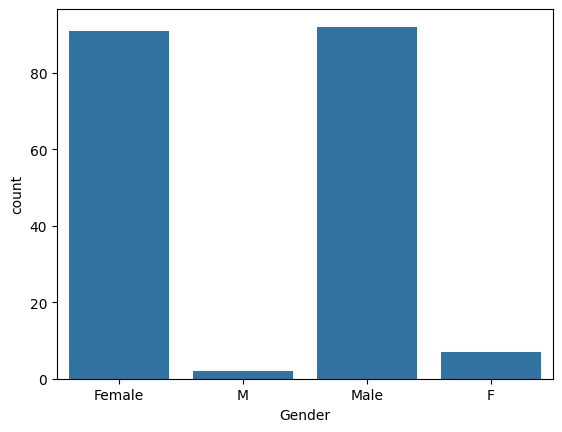

In [37]:
sns.countplot(x=df.Gender)
plt.show()

### 6.2 Replace value in column Gender from  "M" to "Male" and "F" to "Female"

In [38]:
# replace M to Male and replace F to Female
df["Gender"] = df["Gender"].replace({"M": "Male", "F": "Female"})

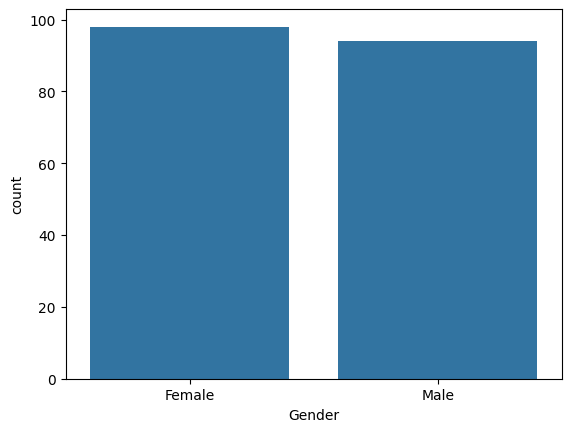

In [39]:
#plot count graph
sns.countplot(x=df.Gender)
plt.show()

In [40]:
df.head()

,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited
0,15634602.0,Laura Gomez,619,France,$60K - $80K,Female,1/1/1957,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES
1,15647311.0,Park Min Woo,608,Spain,Less than $40K,Male,1/1/1954,Single,83807.86,Blue,112542.58,TravelBenefits,NO
2,15619304.0,Michael Chen,502,France,$80K - $120K,Male,1/1/1965,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES
3,15701354.0,Sofia Rossi,699,France,Less than $40K,Female,1/1/1984,Unknown,0.00,Blue,93826.63,OnlineBanking,NO
4,15737888.0,Rachel Sanders,850,Spain,$60K - $80K,Male,1/1/1981,Married,125510.82,Blue,79084.10,Rewards,NO


**#######################################################################################**

## Step3: Feature Engineering

### Check DataFrame information

In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       192 non-null    float64
 1   CustomerName     192 non-null    str    
 2   CreditScore      192 non-null    int64  
 3   Geography        192 non-null    str    
 4   Income_Category  192 non-null    str    
 5   Gender           192 non-null    str    
 6   DateOfBirth      192 non-null    str    
 7   Marital_Status   192 non-null    str    
 8   Balance          192 non-null    float64
 9   Card_Category    192 non-null    str    
 10  EstimatedSalary  192 non-null    float64
 11  ServicesUsed     192 non-null    str    
 12  Exited           192 non-null    str    
dtypes: float64(3), int64(1), str(9)
memory usage: 21.0 KB


### Change Type of CustomerId from float to int by using
* **"ColumnName.astype(int)"**
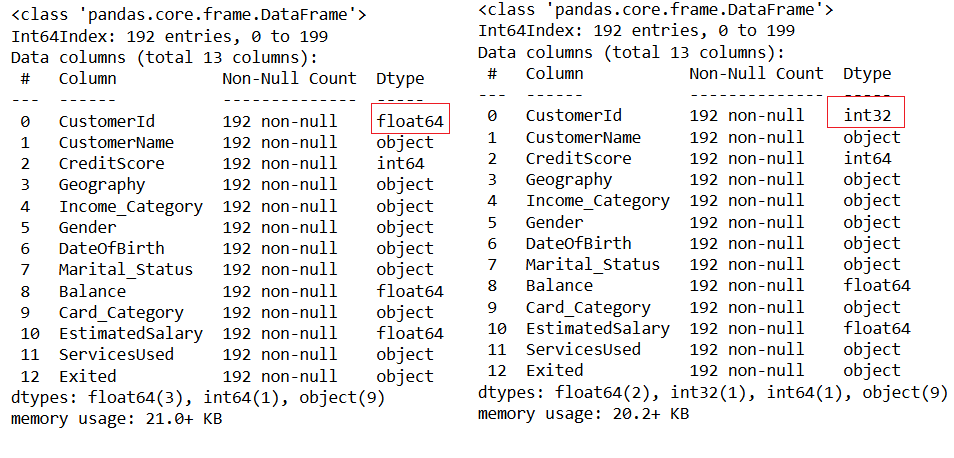

In [42]:
#change datatype "CustomerId" :  is integer
df['CustomerId'] = df.CustomerId.astype(int)


In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       192 non-null    int64  
 1   CustomerName     192 non-null    str    
 2   CreditScore      192 non-null    int64  
 3   Geography        192 non-null    str    
 4   Income_Category  192 non-null    str    
 5   Gender           192 non-null    str    
 6   DateOfBirth      192 non-null    str    
 7   Marital_Status   192 non-null    str    
 8   Balance          192 non-null    float64
 9   Card_Category    192 non-null    str    
 10  EstimatedSalary  192 non-null    float64
 11  ServicesUsed     192 non-null    str    
 12  Exited           192 non-null    str    
dtypes: float64(2), int64(2), str(9)
memory usage: 21.0 KB


### Change Type of DateOfBirth from object to DateTime by using 
* **"columnName = pd.to_datetime(columnName)"**
* 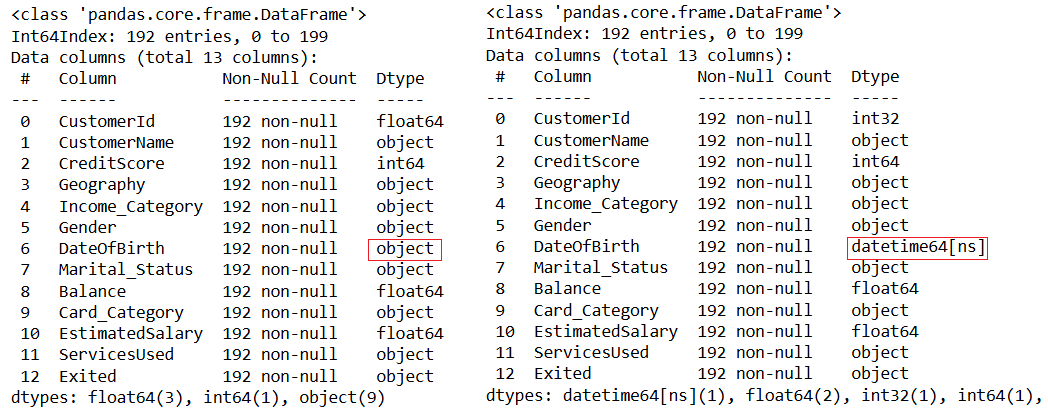

In [44]:
#Change "DateOfBirth" in datatype of datetime

df.DateOfBirth = pd.to_datetime(df.DateOfBirth)

In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerId       192 non-null    int64         
 1   CustomerName     192 non-null    str           
 2   CreditScore      192 non-null    int64         
 3   Geography        192 non-null    str           
 4   Income_Category  192 non-null    str           
 5   Gender           192 non-null    str           
 6   DateOfBirth      192 non-null    datetime64[us]
 7   Marital_Status   192 non-null    str           
 8   Balance          192 non-null    float64       
 9   Card_Category    192 non-null    str           
 10  EstimatedSalary  192 non-null    float64       
 11  ServicesUsed     192 non-null    str           
 12  Exited           192 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(2), str(8)
memory usage: 21.0 KB


In [46]:
df.head()

,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited
0,15634602,Laura Gomez,619,France,$60K - $80K,Female,1957-01-01,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES
1,15647311,Park Min Woo,608,Spain,Less than $40K,Male,1954-01-01,Single,83807.86,Blue,112542.58,TravelBenefits,NO
2,15619304,Michael Chen,502,France,$80K - $120K,Male,1965-01-01,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES
3,15701354,Sofia Rossi,699,France,Less than $40K,Female,1984-01-01,Unknown,0.00,Blue,93826.63,OnlineBanking,NO
4,15737888,Rachel Sanders,850,Spain,$60K - $80K,Male,1981-01-01,Married,125510.82,Blue,79084.10,Rewards,NO


##  Using [ ] to add a new column From datafram df
* **Create new column in "BirthYear" from column "DateOfBirth"**
* **using .dt.year for find the year**

In [47]:
# Create column "BirthYear" from split data from column "DateOfBirth"
df['BirthYear'] = df.DateOfBirth.dt.year


In [48]:
df['BirthYear'].head()

0    1957
1    1954
2    1965
3    1984
4    1981
Name: BirthYear, dtype: int32

In [49]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   CustomerId       192 non-null    int64         
 1   CustomerName     192 non-null    str           
 2   CreditScore      192 non-null    int64         
 3   Geography        192 non-null    str           
 4   Income_Category  192 non-null    str           
 5   Gender           192 non-null    str           
 6   DateOfBirth      192 non-null    datetime64[us]
 7   Marital_Status   192 non-null    str           
 8   Balance          192 non-null    float64       
 9   Card_Category    192 non-null    str           
 10  EstimatedSalary  192 non-null    float64       
 11  ServicesUsed     192 non-null    str           
 12  Exited           192 non-null    str           
 13  BirthYear        192 non-null    int32         
dtypes: datetime64[us](1), float64(2), int32(1), int64(2), str(

### Create new column "Age" from Current DataTime -  BirthYear
* **import package: from datetime import datetime as dt**
* **convert type to interger using fuction astype(int)**

In [50]:
from datetime import datetime as dt
print(dt.today().year)

2026


In [51]:
# Create column "Age" from Current DataTime - BirthYear

df["Age"] = dt.today().year - (df['BirthYear'])


In [52]:
#show 5 first rows
df.head()

,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age
0,15634602,Laura Gomez,619,France,$60K - $80K,Female,1957-01-01,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69
1,15647311,Park Min Woo,608,Spain,Less than $40K,Male,1954-01-01,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72
2,15619304,Michael Chen,502,France,$80K - $120K,Male,1965-01-01,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61
3,15701354,Sofia Rossi,699,France,Less than $40K,Female,1984-01-01,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42
4,15737888,Rachel Sanders,850,Spain,$60K - $80K,Male,1981-01-01,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45


### Using apply() function used to manipulate values
* **#Create column "FirstName" to split data from feature "CustomerName"**
* **df['FirstName'] = df.apply(CustomerName**

In [53]:
# Function split Full name to FirstName and LastName, then return FirstName
def splitFullName(name):
    split = name.split(' ')
    firstName= split[0]
    return firstName

In [54]:
#Create column "FirstName" to split data from feature "CustomerName"
df['FirstName'] = df["CustomerName"].apply(splitFullName)


In [55]:
# data in colunm FirstName
df.head()

,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName
0,15634602,Laura Gomez,619,France,$60K - $80K,Female,1957-01-01,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura
1,15647311,Park Min Woo,608,Spain,Less than $40K,Male,1954-01-01,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park
2,15619304,Michael Chen,502,France,$80K - $120K,Male,1965-01-01,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael
3,15701354,Sofia Rossi,699,France,Less than $40K,Female,1984-01-01,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia
4,15737888,Rachel Sanders,850,Spain,$60K - $80K,Male,1981-01-01,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel


### Using transform() function used to manipulate values
* **#Create column "LastName" to split data from feature "CustomerName"**
* **df['LastName'] = df['CustomerName'].transform(lambda row: row.split(' ')[1])**

In [56]:
# Create column "LastName" to split data from feature "CustomerName"
# Using lambda equivalent

df['LastName'] = df['CustomerName'].transform(lambda row: row.split(' ')[1])

In [57]:
df.head()

,CustomerId,CustomerName,CreditScore,Geography,Income_Category,Gender,DateOfBirth,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName
0,15634602,Laura Gomez,619,France,$60K - $80K,Female,1957-01-01,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez
1,15647311,Park Min Woo,608,Spain,Less than $40K,Male,1954-01-01,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park,Min
2,15619304,Michael Chen,502,France,$80K - $120K,Male,1965-01-01,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen
3,15701354,Sofia Rossi,699,France,Less than $40K,Female,1984-01-01,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi
4,15737888,Rachel Sanders,850,Spain,$60K - $80K,Male,1981-01-01,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel,Sanders


### Drop 2 columns of "CustomerId", "CustomerName" and "DateOfBirth"
* **.drop([ ] , axis=1 ,inplace=True)**

In [58]:
#Drop column "CustomerId", "CustomerName" and "DateOfBirth"

df.drop(['CustomerId', 'CustomerName','DateOfBirth'], axis=1, inplace = True)


In [59]:
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName
0,619,France,$60K - $80K,Female,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez
1,608,Spain,Less than $40K,Male,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park,Min
2,502,France,$80K - $120K,Male,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen
3,699,France,Less than $40K,Female,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi
4,850,Spain,$60K - $80K,Male,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel,Sanders


### Encoding Categorical Features: One-hot encoding
* **Using dummies values approach: df2 = pandas.get_dummies(df[columnName])**
* **Using pandas concat function for concatenating pandas object into Dataframe output**
* **df = pd.concat([df,df2],axis=1)**


In [60]:
#Transform column "Gender" all the labels 'Male', 'Female' into 1,0 binary columns

df2 = pd.get_dummies(df['Gender'])

In [61]:
df2.head()

,Female,Male
0,True,False
1,False,True
2,False,True
3,True,False
4,False,True


In [62]:
#Using pandas concat() function for concatenating pandas objects into a Data Frame output.

df = pd.concat([df,df2],axis=1)

In [63]:
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName,Female,Male
0,619,France,$60K - $80K,Female,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez,True,False
1,608,Spain,Less than $40K,Male,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park,Min,False,True
2,502,France,$80K - $120K,Male,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen,False,True
3,699,France,Less than $40K,Female,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi,True,False
4,850,Spain,$60K - $80K,Male,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel,Sanders,False,True


### One-hot encoding :: using Scikit learn
* **Using sci-kit learn library values approach: column "Marital_Status", from sklearn.preprocessing import OneHotEncoder**
* **encoder = preprocessing.OneHotEncoder()**
* **encoder_features = pd.DataFrame(encoder.fit_transform(df[['Marital_Status']]).toarray()**
* **df.join(encoder_features)**

In [64]:
#Using package from sklearn.preprocessing import for using the OneHotEncoder function
from sklearn.preprocessing import OneHotEncoder

#creating instance of one-hot-encoder
encoder = OneHotEncoder()


#perform one-hot encoding on 'team' column 
encoder_features = pd.DataFrame(encoder.fit_transform(df[['Marital_Status']]).toarray())


#merge one-hot encoded columns back with original DataFrame
df = df.join(encoder_features)
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName,Female,Male,0,1,2,3
0,619,France,$60K - $80K,Female,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez,True,False,0.0,1.0,0.0,0.0
1,608,Spain,Less than $40K,Male,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park,Min,False,True,0.0,0.0,1.0,0.0
2,502,France,$80K - $120K,Male,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen,False,True,0.0,1.0,0.0,0.0
3,699,France,Less than $40K,Female,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi,True,False,0.0,0.0,0.0,1.0
4,850,Spain,$60K - $80K,Male,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel,Sanders,False,True,0.0,1.0,0.0,0.0


In [65]:
df['Marital_Status'].unique()

<StringArray>
['Married', 'Single', 'Unknown', 'Divorced']
Length: 4, dtype: str

### Rename colunm 
* **{0:'Single', 1:'Married', 2:'Unknown', 3:'Divorced'}, axis=1, inplace=True**

In [66]:
#Rename colunm 0,1,2,3 to 'Single', 'Married', 'Unknown', 'Divorced'
df.rename({0:'Single', 1:'Married', 2:'Unknown', 3:'Divorced'}, axis=1,inplace=True)


In [67]:
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName,Female,Male,Single,Married,Unknown,Divorced
0,619,France,$60K - $80K,Female,Married,0.00,Blue,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez,True,False,0.0,1.0,0.0,0.0
1,608,Spain,Less than $40K,Male,Single,83807.86,Blue,112542.58,TravelBenefits,NO,1954,72,Park,Min,False,True,0.0,0.0,1.0,0.0
2,502,France,$80K - $120K,Male,Married,159660.80,Blue,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen,False,True,0.0,1.0,0.0,0.0
3,699,France,Less than $40K,Female,Unknown,0.00,Blue,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi,True,False,0.0,0.0,0.0,1.0
4,850,Spain,$60K - $80K,Male,Married,125510.82,Blue,79084.10,Rewards,NO,1981,45,Rachel,Sanders,False,True,0.0,1.0,0.0,0.0


### Label Encoding : categorical column "Card_Category"
* **converting type of columns to 'category'**
* **df['Card_Category'] = df['Card_Category'].astype('category')**
* **Assigning numerical values and storing in another column**
* **df['Card_Cat_Label'] = df['Card_Category'].cat.codes**

In [68]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      192 non-null    int64  
 1   Geography        192 non-null    str    
 2   Income_Category  192 non-null    str    
 3   Gender           192 non-null    str    
 4   Marital_Status   192 non-null    str    
 5   Balance          192 non-null    float64
 6   Card_Category    192 non-null    str    
 7   EstimatedSalary  192 non-null    float64
 8   ServicesUsed     192 non-null    str    
 9   Exited           192 non-null    str    
 10  BirthYear        192 non-null    int32  
 11  Age              192 non-null    int32  
 12  FirstName        192 non-null    str    
 13  LastName         192 non-null    str    
 14  Female           192 non-null    bool   
 15  Male             192 non-null    bool   
 16  Single           187 non-null    float64
 17  Married          187 non-null   

In [69]:
# converting type of columns to 'category'
df['Card_Category'] = df['Card_Category'].astype('category')


In [70]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      192 non-null    int64   
 1   Geography        192 non-null    str     
 2   Income_Category  192 non-null    str     
 3   Gender           192 non-null    str     
 4   Marital_Status   192 non-null    str     
 5   Balance          192 non-null    float64 
 6   Card_Category    192 non-null    category
 7   EstimatedSalary  192 non-null    float64 
 8   ServicesUsed     192 non-null    str     
 9   Exited           192 non-null    str     
 10  BirthYear        192 non-null    int32   
 11  Age              192 non-null    int32   
 12  FirstName        192 non-null    str     
 13  LastName         192 non-null    str     
 14  Female           192 non-null    bool    
 15  Male             192 non-null    bool    
 16  Single           187 non-null    float64 
 17  Married      

In [71]:
# Assigning numerical values to Card_Category column
# With df[columnName] = df[columnName].cat.codes**

df['Card_Category'] = df['Card_Category'].cat.codes


#show data first 5 rows
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,BirthYear,Age,FirstName,LastName,Female,Male,Single,Married,Unknown,Divorced
0,619,France,$60K - $80K,Female,Married,0.00,0,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,1957,69,Laura,Gomez,True,False,0.0,1.0,0.0,0.0
1,608,Spain,Less than $40K,Male,Single,83807.86,0,112542.58,TravelBenefits,NO,1954,72,Park,Min,False,True,0.0,0.0,1.0,0.0
2,502,France,$80K - $120K,Male,Married,159660.80,0,113931.57,"OnlineBanking, MobileApp, Rewards",YES,1965,61,Michael,Chen,False,True,0.0,1.0,0.0,0.0
3,699,France,Less than $40K,Female,Unknown,0.00,0,93826.63,OnlineBanking,NO,1984,42,Sofia,Rossi,True,False,0.0,0.0,0.0,1.0
4,850,Spain,$60K - $80K,Male,Married,125510.82,0,79084.10,Rewards,NO,1981,45,Rachel,Sanders,False,True,0.0,1.0,0.0,0.0


In [72]:
df.info()

<class 'pandas.DataFrame'>
Index: 192 entries, 0 to 199
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      192 non-null    int64  
 1   Geography        192 non-null    str    
 2   Income_Category  192 non-null    str    
 3   Gender           192 non-null    str    
 4   Marital_Status   192 non-null    str    
 5   Balance          192 non-null    float64
 6   Card_Category    192 non-null    int8   
 7   EstimatedSalary  192 non-null    float64
 8   ServicesUsed     192 non-null    str    
 9   Exited           192 non-null    str    
 10  BirthYear        192 non-null    int32  
 11  Age              192 non-null    int32  
 12  FirstName        192 non-null    str    
 13  LastName         192 non-null    str    
 14  Female           192 non-null    bool   
 15  Male             192 non-null    bool   
 16  Single           187 non-null    float64
 17  Married          187 non-null   

### Label Encoding : scikit Learn
* **column "Exited"**
* **labelencoder = LabelEncoder()**
* **df['Exited_Label'] = labelencoder.fit_transform(df['Exited'])**

In [73]:
#Using package from sklearn.preprocessing import for using the LabelEncoder function
from sklearn.preprocessing import LabelEncoder


# creating instance of labelencoder
labelencoder = LabelEncoder()


# Assigning numerical values and storing in another column
df['Exited_Label'] = labelencoder.fit_transform(df['Exited'])


In [74]:
df.head()

,CreditScore,Geography,Income_Category,Gender,Marital_Status,Balance,Card_Category,EstimatedSalary,ServicesUsed,Exited,...,Age,FirstName,LastName,Female,Male,Single,Married,Unknown,Divorced,Exited_Label
0,619,France,$60K - $80K,Female,Married,0.00,0,101348.88,"OnlineBanking, MobileApp, TravelBenefits",YES,...,69,Laura,Gomez,True,False,0.0,1.0,0.0,0.0,1
1,608,Spain,Less than $40K,Male,Single,83807.86,0,112542.58,TravelBenefits,NO,...,72,Park,Min,False,True,0.0,0.0,1.0,0.0,0
2,502,France,$80K - $120K,Male,Married,159660.80,0,113931.57,"OnlineBanking, MobileApp, Rewards",YES,...,61,Michael,Chen,False,True,0.0,1.0,0.0,0.0,1
3,699,France,Less than $40K,Female,Unknown,0.00,0,93826.63,OnlineBanking,NO,...,42,Sofia,Rossi,True,False,0.0,0.0,0.0,1.0,0
4,850,Spain,$60K - $80K,Male,Married,125510.82,0,79084.10,Rewards,NO,...,45,Rachel,Sanders,False,True,0.0,1.0,0.0,0.0,0


### MultiLabelBinarizer (Multi-label column)
* Steps:
* 1. Split the string into a list
* 2. Apply `MultiLabelBinarizer`
* 3. Join the encoded columns back to the DataFrame


In [75]:
from sklearn.preprocessing import MultiLabelBinarizer
# 1) Convert the string column to list-of-labels 
# .str.split(',') turns "OnlineBanking", "MobileApp", "TravelBenefits"" into ["OnlineBanking", "MobileApp", "TravelBenefits"]
services_list = df['ServicesUsed'].str.split(',')


In [76]:

# 2) Apply MultiLabelBinarizer
mlb = MultiLabelBinarizer()
multilabel_encoded = mlb.fit_transform(services_list)

# 3) Make DataFrame with same index
encoded_df = pd.DataFrame(multilabel_encoded, columns=mlb.classes_)

# 4) Combine 
df = pd.concat([df, encoded_df], axis=1)


In [77]:
encoded_df.head()

,Cashback,Insurance,MobileApp,OnlineBanking,Rewards,TravelBenefits,Cashback,Insurance,MobileApp,OnlineBanking,Rewards,TravelBenefits
0,0,0,1,0,0,1,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0,1,0,1,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,1,0


### Create a new datframe df_normalize
* **Select only column [["Balance","EstimatedSalary","Female","Male","Single","Card_Category", "Exited_Label"]] from df_final**

In [78]:
df_normalize = df.filter(["Balance","EstimatedSalary","Female","Male","Single","Card_Category", "Exited_Label"])
df_normalize.head()

,Balance,EstimatedSalary,Female,Male,Single,Card_Category,Exited_Label
0,0.00,101348.88,True,False,0.0,0.0,1.0
1,83807.86,112542.58,False,True,0.0,0.0,0.0
2,159660.80,113931.57,False,True,0.0,0.0,1.0
3,0.00,93826.63,True,False,0.0,0.0,0.0
4,125510.82,79084.10,False,True,0.0,0.0,0.0


### Feature Scaling
* **Create a scaler object: scaler = preprocessing.MinMaxScaler()**
* **Fit and transform the data: df_normalize = pd.DataFrame(scaler.fit_transform(df_normalize), columns=df_normalize.columns)**

In [79]:
#Using package from sklearn.preprocessing import for using the MinMaxScaler function

from sklearn.preprocessing import MinMaxScaler

# create a scaler object
scaler = MinMaxScaler()

# fit and transform the data
df_norm = pd.DataFrame(scaler.fit_transform(df_normalize), columns=df_normalize.columns)
df_norm.head()

,Balance,EstimatedSalary,Female,Male,Single,Card_Category,Exited_Label
0,0.000000,0.505956,1.0,0.0,0.0,0.0,1.0
1,0.393194,0.562171,0.0,1.0,0.0,0.0,0.0
2,0.749067,0.569146,0.0,1.0,0.0,0.0,1.0
3,0.000000,0.468180,1.0,0.0,0.0,0.0,0.0
4,0.588848,0.394143,0.0,1.0,0.0,0.0,0.0
